Found 3 range-doppler files
Loading: range_doppler.csv
Loading: range_doppler_2026-05-24_16-29-03.csv
Loading: range_doppler_2026-05-25_13-10-03.csv


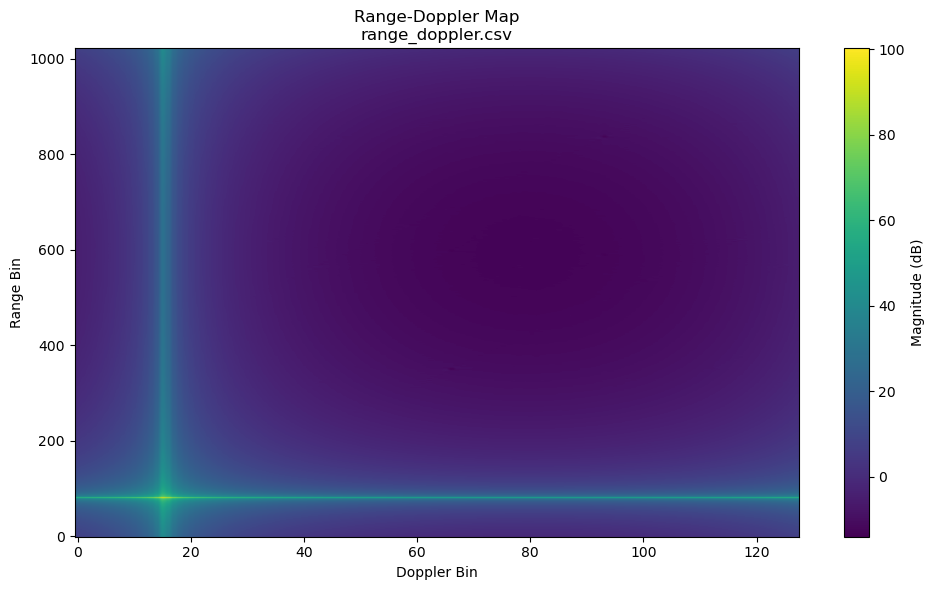

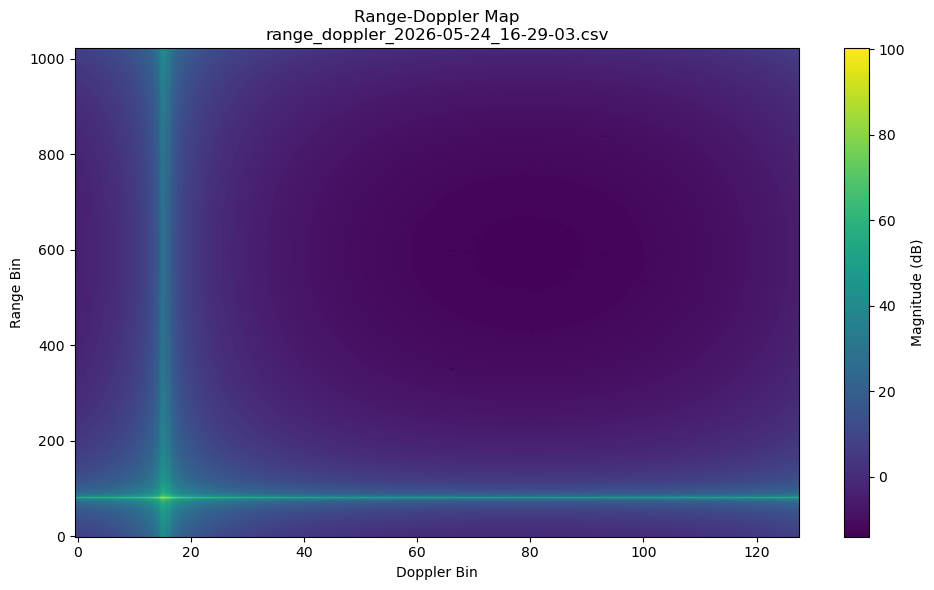

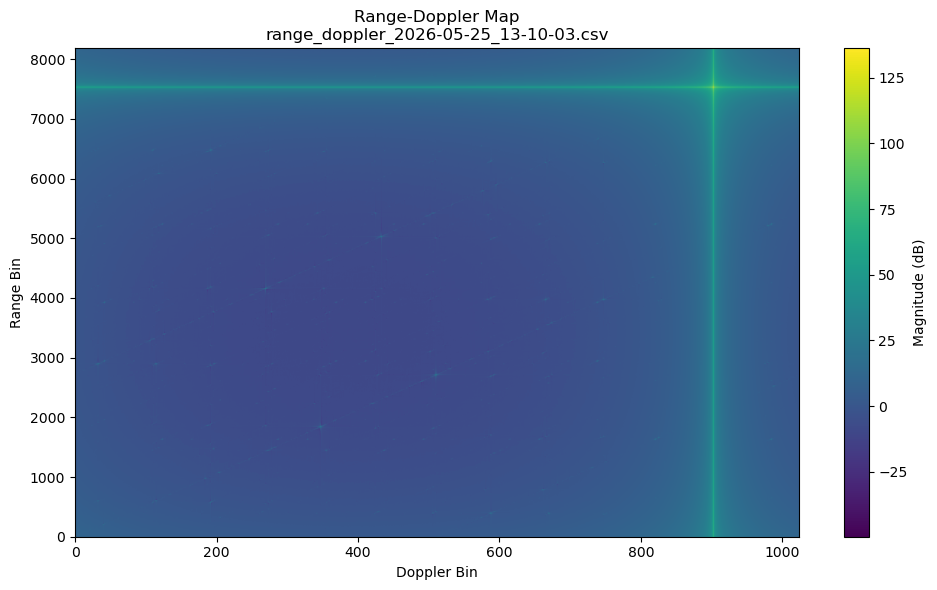

In [1]:
import pathlib
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# Locate all CSV files
# -----------------------------------------------------------------------------

data_dir = pathlib.Path("data")

csv_files = sorted(data_dir.glob("*.csv"))

if not csv_files:
    raise RuntimeError("No CSV files found in ./data")

print(f"Found {len(csv_files)} range-doppler files")

# -----------------------------------------------------------------------------
# Plot all files
# -----------------------------------------------------------------------------

for csv_file in csv_files:

    print(f"Loading: {csv_file.name}")

    # Load CSV
    data = np.loadtxt(csv_file, delimiter=",")

    # Convert to dB scale
    data_db = 20 * np.log10(data + 1e-6)

    # Create figure
    plt.figure(figsize=(10, 6))

    plt.imshow(
        data_db,
        aspect="auto",
        origin="lower"
    )

    plt.colorbar(label="Magnitude (dB)")

    plt.xlabel("Doppler Bin")
    plt.ylabel("Range Bin")

    # Filename becomes identifying label
    plt.title(f"Range-Doppler Map\n{csv_file.name}")

    plt.tight_layout()

# -----------------------------------------------------------------------------
# Display all plots
# -----------------------------------------------------------------------------

plt.show()